In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = "../data/EMG_data_for_gestures-master"

def load_all_subjects(root):
    all_dfs = []
    
    COLUMNS = [
        "time",
        "channel1","channel2","channel3","channel4",
        "channel5","channel6","channel7","channel8",
        "class"
    ]

    for subject in sorted(os.listdir(root)):
        subject_path = os.path.join(root, subject)
        if not os.path.isdir(subject_path):
            continue

        for file in sorted(os.listdir(subject_path)):
            if file.endswith(".txt"):
                df = pd.read_csv(
                    os.path.join(subject_path, file),
                    sep="\t",
                    header=None,
                    skiprows=1
                )
                df.columns = COLUMNS
                df["subject"] = subject
                all_dfs.append(df)

    return pd.concat(all_dfs, ignore_index=True)

data = load_all_subjects(DATA_ROOT)

# Clean labels
data = data.dropna(subset=["class"])
data["class"] = data["class"].astype(int)

print("Total samples:", len(data))

Total samples: 4237907


In [2]:
# Step 2: Windowing (250 ms, majority vote)

CHANNELS = [
    "channel1","channel2","channel3","channel4",
    "channel5","channel6","channel7","channel8"
]

WINDOW_SIZE = 250
STEP_SIZE = 250  # non-overlapping

def window_per_subject(data):
    windows = []
    labels = []
    subjects = []

    for subject in np.unique(data["subject"]):
        df_sub = data[data["subject"] == subject]

        start = 0
        while start + WINDOW_SIZE <= len(df_sub):
            window = df_sub.iloc[start:start + WINDOW_SIZE]

            label = window["class"].mode()[0]

            windows.append(window[CHANNELS].values)
            labels.append(label)
            subjects.append(subject)

            start += WINDOW_SIZE

    return np.array(windows), np.array(labels), np.array(subjects)

X_w, y_w, subj_w = window_per_subject(data)

print("Total windows:", len(y_w))
print("Window shape:", X_w.shape)


Total windows: 16934
Window shape: (16934, 250, 8)


Window-level label counts:
0    10880
1     1004
2      980
3      997
4     1005
5     1005
6     1009
7       54
Name: count, dtype: int64


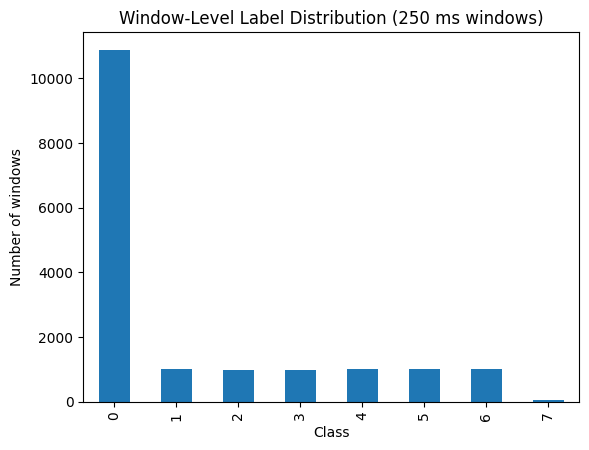

In [3]:
# Step 2.1: Window-level label distribution

import pandas as pd
import matplotlib.pyplot as plt

window_label_counts = pd.Series(y_w).value_counts().sort_index()

print("Window-level label counts:")
print(window_label_counts)

window_label_counts.plot(kind="bar")
plt.title("Window-Level Label Distribution (250 ms windows)")
plt.xlabel("Class")
plt.ylabel("Number of windows")
plt.show()


In [4]:
# Step 3: Prepare multi-class dataset (gestures 1–6)

mask_multi = np.isin(y_w, [1,2,3,4,5,6])

X_multi = X_w[mask_multi]
y_multi = y_w[mask_multi]
subj_multi = subj_w[mask_multi]

print("Total windows in multi-class task:", len(y_multi))
print("\nClass distribution:")

import pandas as pd
print(pd.Series(y_multi).value_counts().sort_index())

Total windows in multi-class task: 6000

Class distribution:
1    1004
2     980
3     997
4    1005
5    1005
6    1009
Name: count, dtype: int64


In [5]:

def extract_rms_mav(windows):
    features = []
    for w in windows:
        rms = np.sqrt(np.mean(w ** 2, axis=0))
        mav = np.mean(np.abs(w), axis=0)
        features.append(np.concatenate([rms, mav]))
    return np.array(features)

In [6]:
# Step 3: Feature extraction for multi-class task (RMS + MAV)

X_multi_features = extract_rms_mav(X_multi)

print("Multi-class feature matrix shape:", X_multi_features.shape)

Multi-class feature matrix shape: (6000, 16)


In [7]:
# Step 4: Subject-wise split for multi-class task

unique_subjects_multi = np.unique(subj_multi)

print("Total subjects:", len(unique_subjects_multi))
print("Subjects:", unique_subjects_multi)

# Hold out last 3 subjects for testing (same protocol as binary)
test_subjects_multi = unique_subjects_multi[-3:]

print("\nTest subjects:", test_subjects_multi)

train_mask_multi = ~np.isin(subj_multi, test_subjects_multi)
test_mask_multi = np.isin(subj_multi, test_subjects_multi)

X_train_multi = X_multi_features[train_mask_multi]
y_train_multi = y_multi[train_mask_multi]

X_test_multi = X_multi_features[test_mask_multi]
y_test_multi = y_multi[test_mask_multi]

print("\nTrain samples:", len(y_train_multi))
print("Test samples :", len(y_test_multi))

Total subjects: 36
Subjects: ['01' '02' '03' '04' '05' '06' '07' '08' '09' '10' '11' '12' '13' '14'
 '15' '16' '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28'
 '29' '30' '31' '32' '33' '34' '35' '36']

Test subjects: ['34' '35' '36']

Train samples: 5515
Test samples : 485


In [8]:
print(X_train_multi.shape)


(5515, 16)


In [9]:
# Step 5: Scaling for multi-class task (no data leakage)

from sklearn.preprocessing import StandardScaler

scaler_multi = StandardScaler()

# Fit only on training data
X_train_multi_scaled = scaler_multi.fit_transform(X_train_multi)

# Apply same scaler to test data
X_test_multi_scaled = scaler_multi.transform(X_test_multi)

print("Scaled train mean (first 5 features):",
      X_train_multi_scaled.mean(axis=0)[:5])

print("Scaled train std (first 5 features):",
      X_train_multi_scaled.std(axis=0)[:5])

Scaled train mean (first 5 features): [-1.38794989e-15  3.54037339e-15  4.18381960e-15 -4.52991125e-15
 -7.45168005e-16]
Scaled train std (first 5 features): [1. 1. 1. 1. 1.]


In [10]:
# Step 6: Train multi-class Logistic Regression

from sklearn.linear_model import LogisticRegression

clf_multi = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    n_jobs=-1
)

clf_multi.fit(X_train_multi_scaled, y_train_multi)

print("Multi-class Logistic Regression training complete.")

Multi-class Logistic Regression training complete.


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


=== Multi-class Results ===

Accuracy : 0.8845360824742268
Macro F1 : 0.8840924062096857

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        82
           2       1.00      0.80      0.89        81
           3       0.72      0.99      0.84        80
           4       0.93      0.81      0.87        81
           5       0.91      0.94      0.92        83
           6       0.82      0.76      0.79        78

    accuracy                           0.88       485
   macro avg       0.90      0.88      0.88       485
weighted avg       0.90      0.88      0.89       485



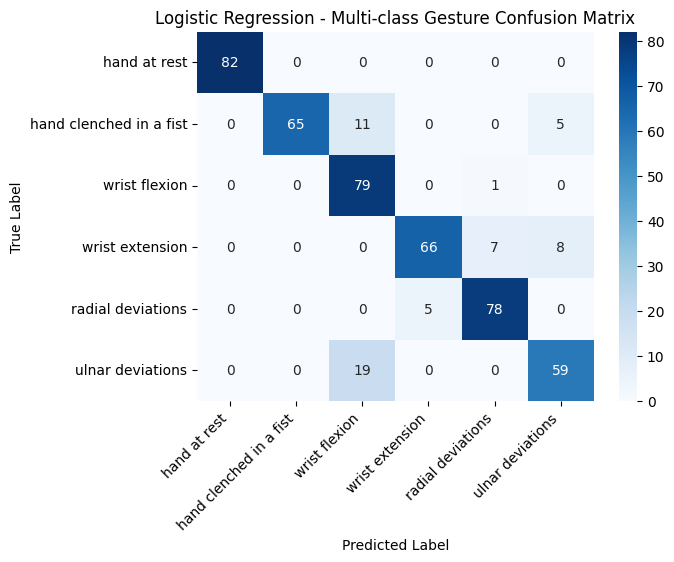

In [11]:
# Step 7: Multi-class evaluation

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred_multi = clf_multi.predict(X_test_multi_scaled)

# Metrics
accuracy_multi = accuracy_score(y_test_multi, y_pred_multi)
macro_f1_multi = f1_score(y_test_multi, y_pred_multi, average="macro")

print("=== Multi-class Results ===")

print("\nAccuracy :", accuracy_multi)
print("Macro F1 :", macro_f1_multi)

print("\nClassification Report:")
print(classification_report(y_test_multi, y_pred_multi))

# Confusion Matrix
cm_multi = confusion_matrix(y_test_multi, y_pred_multi)

class_names = [
    "hand at rest",
    "hand clenched in a fist",
    "wrist flexion",
    "wrist extension",
    "radial deviations",
    "ulnar deviations"
]

sns.heatmap(
    cm_multi,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.title("Logistic Regression - Multi-class Gesture Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

Random Forest Accuracy: 0.8845
Random Forest Macro F1: 0.8827
Random Forest Precision: 0.8911
Random Forest Recall: 0.8834
Random Forest Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        82
           2       1.00      0.96      0.98        81
           3       0.75      0.99      0.85        80
           4       0.83      0.83      0.83        81
           5       0.96      0.84      0.90        83
           6       0.82      0.68      0.74        78

    accuracy                           0.88       485
   macro avg       0.89      0.88      0.88       485
weighted avg       0.89      0.88      0.88       485



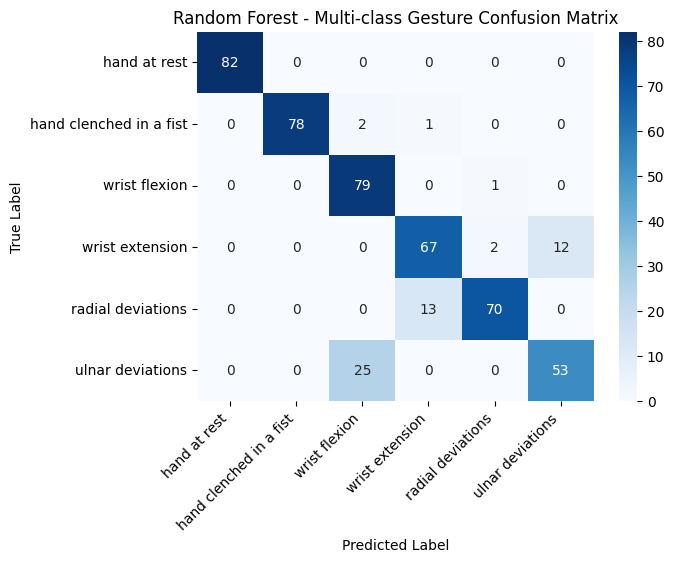

In [12]:
# Step 6: Train multi-class random forest
from sklearn.metrics import precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
rf_multi = RandomForestClassifier(n_estimators=20, random_state=42)
rf_multi.fit(X_train_multi_scaled, y_train_multi)
y_pred_rf_multi = rf_multi.predict(X_test_multi_scaled)
accuracy_rf_multi = accuracy_score(y_test_multi, y_pred_rf_multi)
f1_rf_multi = f1_score(y_test_multi, y_pred_rf_multi, average="macro")
precision_rf_multi = precision_score(y_test_multi, y_pred_rf_multi, average="macro")
recall_rf_multi = recall_score(y_test_multi, y_pred_rf_multi, average="macro")
print(f"Random Forest Accuracy: {accuracy_rf_multi:.4f}")
print(f"Random Forest Macro F1: {f1_rf_multi:.4f}")
print(f"Random Forest Precision: {precision_rf_multi:.4f}")
print(f"Random Forest Recall: {recall_rf_multi:.4f}")
cm_rf_multi = confusion_matrix(y_test_multi, y_pred_rf_multi)

report_rf_multi = classification_report(y_test_multi, y_pred_rf_multi)
print(f"Random Forest Classification Report:\n{report_rf_multi}")

sns.heatmap(
    cm_rf_multi,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Random Forest - Multi-class Gesture Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
